# API Calling to ChatGPT Lab

**Scenario:** You're working as an AI automation specialist for an e-commerce company. Your team needs to automate the creation of product listings from product images and basic information. Instead of manually writing descriptions, you'll use ChatGPT's vision capabilities to generate compelling product listings automatically. This will save hours of manual work and ensure consistent, high-quality product descriptions.

## Introduction
Welcome to the ChatGPT API lab! In this exercise, you'll learn how to integrate OpenAI's ChatGPT API into your applications. Specifically, you'll use GPT-4 Vision to analyze product images and generate professional product listings.

In [1]:
from datasets import load_dataset
import requests
from PIL import Image
from pathlib import Path
import pandas as pd
import base64
from io import BytesIO
import os
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel
from typing import List

/home/javi/projects/ironhack_AI_integration/W1D4_api_calling_chatgpt/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Setting Up OpenAI API Access
**Objective:** Get API access and set up authentication.

In [2]:
load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("API key not loaded")

client = OpenAI(api_key=api_key)

## Step 2: Preparing the Dataset
**Objective:** Download and set up the e-commerce product dataset.

**What to do:**
- Download the e-commerce product dataset
- Organize product images and metadata
- Create a data structure for products

**Dataset Options:**
**Option 1:** Products-10K Dataset (HuggingFace)
- Link: Fashion Product Images on HuggingFace:  [link text](https://huggingface.co/datasets/ashraq/fashion-product-images-small)
- Contains diverse product images
- Can be loaded directly with Python

**Option 2:** Any Other Dataset
- We recommend using a dataset with product images and metadata
- Ensure you have at least 10-20 products for testing
- Otherwise, you are free to use any dataset on kaggle or huggingface

In [3]:
# Load dataset from HuggingFace
print("Loading product dataset...")
try:
    # Try loading the dataset
    dataset = load_dataset("ashraq/fashion-product-images-small", split="train[:100]")  # First 100 samples
    print(f"✓ Loaded {len(dataset)} products")
    
    # Convert to pandas for easier manipulation
    products_df = pd.DataFrame(dataset)
    print(f"Dataset columns: {products_df.columns.tolist()}")
    
except Exception as e:
    print(f"⚠ Could not load HuggingFace dataset: {e}")
    print("Using local images instead...")
    
    # Alternative: Use local images
    # Create a products.json file with product information
    products_data = [
        {
            "id": 1,
            "name": "Wireless Headphones",
            "price": 79.99,
            "category": "Electronics",
            "image_path": "images/product1.jpg"
        },
        # Add more products...
    ]
    products_df = pd.DataFrame(products_data)
 
# Create images directory
images_dir = Path("product_images")
images_dir.mkdir(exist_ok=True)
 
print(f"\n✓ Dataset prepared!")
print(f"  Total products: {len(products_df)}")

Loading product dataset...


✓ Loaded 100 products
Dataset columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image']

✓ Dataset prepared!
  Total products: 100


In [4]:
# Visualizing the first few products of the dataset 
products_df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,<PIL.JpegImagePlugin.JpegImageFile image mode=...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,<PIL.JpegImagePlugin.JpegImageFile image mode=...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,<PIL.Image.Image image mode=L size=60x80 at 0x...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,<PIL.JpegImagePlugin.JpegImageFile image mode=...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,<PIL.Image.Image image mode=RGB size=60x80 at ...


In [5]:
# Visualizing the image column of the dataset 
products_df["image"]

0     <PIL.JpegImagePlugin.JpegImageFile image mode=...
1     <PIL.JpegImagePlugin.JpegImageFile image mode=...
2     <PIL.Image.Image image mode=L size=60x80 at 0x...
3     <PIL.JpegImagePlugin.JpegImageFile image mode=...
4     <PIL.Image.Image image mode=RGB size=60x80 at ...
                            ...                        
95    <PIL.JpegImagePlugin.JpegImageFile image mode=...
96    <PIL.JpegImagePlugin.JpegImageFile image mode=...
97    <PIL.Image.Image image mode=RGB size=60x80 at ...
98    <PIL.Image.Image image mode=RGB size=60x80 at ...
99    <PIL.Image.Image image mode=RGB size=60x80 at ...
Name: image, Length: 100, dtype: object

## Step 3: Encoding Images for API
**Objective:** Convert product images to base64 format for API transmission.

In [6]:
# Defining a function to convert PIL images to base64 for embedding in HTML
def pil_to_base64(img):
    buffer = BytesIO()
    img.save(buffer, format="PNG") 
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

# converting all column containing images to base64:
products_df["image_base64"] = products_df["image"].apply(pil_to_base64)

## Step 4: Creating the Product Listing Prompt
**Objective:** Design an effective prompt for generating product listings.

**What to do:**
- Create a prompt template
- Include product metadata
- Specify the desired output format

In [7]:
def create_product_listing_prompt(df_row):
    """
    Create a prompt for generating product listings.
    Parameters:
    - product_name: Name of the product
    - price: Price of the product
    - category: Product category
    - additional_info: Optional additional information
    Returns:
    - Formatted prompt string
    """
    prompt = f"""You are an expert e-commerce copywriter. Analyze the product image and create a compelling product listing.
Product Information:
- ID: {df_row['id']}
- Gender: {df_row['gender']}
- Category: {df_row['masterCategory']}; {df_row['subCategory']}; {df_row['articleType']}
- Colour: {df_row['baseColour']}
- Season, Usage: {df_row['season']}; {df_row['usage']}
- Year: {df_row['year']:.0f}
- Display name: {df_row['productDisplayName']}
Please create a professional product listing that includes:
1. **Product Title** (catchy, SEO-friendly, 60 characters max)
2. **Product Description** (detailed, 150-200 words)
   - Highlight key features and benefits
   - Use persuasive language
   - Include relevant details visible in the image
3. **Key Features** (bullet points, 5-7 items)
4. **SEO Keywords** (comma-separated, 10-15 relevant keywords)
Format your response as JSON with the following structure:
{{
    "title": "Product title here",
    "description": "Full description here",
    "features": ["Feature 1", "Feature 2", ...],
    "keywords": "keyword1, keyword2, ..."
}}
Be specific about what you see in the image. Mention colors, materials, design elements, and any distinctive features."""
    return prompt



In [ ]:
# Test prompt creation
test_prompt = create_product_listing_prompt(products_df.iloc[0])
print("\n" + "="*50)
print("PROMPT TEMPLATE")
print("="*50)
print(test_prompt)  


PROMPT TEMPLATE
You are an expert e-commerce copywriter. Analyze the product image and create a compelling product listing.
Product Information:
- ID: 15970
- Gender: Men
- Category: Apparel; Topwear; Shirts
- Colour: Navy Blue
- Season, Usage: Fall; Casual
- Year: 2011
- Display name: Turtle Check Men Navy Blue Shirt
Please create a professional product listing that includes:
1. **Product Title** (catchy, SEO-friendly, 60 characters max)
2. **Product Description** (detailed, 150-200 words)
   - Highlight key f...


## Step 5: Calling the ChatGPT API with Vision
**Objective:** Send image and text to ChatGPT API and receive response.

**What to do:**
- Prepare the API request with image and prompt
- Call the ChatGPT API
- Handle the response
- Parse JSON output

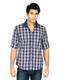

In [9]:
def generate_listing_for_row(df_row, model="gpt-4o"):
    prompt = create_product_listing_prompt(df_row)

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{df_row['image_base64']}"
                        }
                    }
                ]
            }
        ]
    )

    return response.choices[0].message.content


# generating listing for the first row and saving it in a new column
idx = 0
row = products_df.iloc[idx]

result = generate_listing_for_row(row)

products_df.loc[products_df.index[idx], "listing_raw"] = result

display(row["image"])



In [10]:
# Create a function to generate and display listings for a range of rows
def generate_and_display_range(df, idx_start, idx_end):
    for idx, row in df.iloc[idx_start:idx_end].iterrows():
        print(f"\n===== ROW {idx} =====")

        try:
            result = generate_listing_for_row(row)
            df.loc[idx, "listing_raw"] = result

            display(row["image"])
            print(result)

        except Exception as e:
            df.loc[idx, "listing_raw"] = None
            print(f"Row {idx} failed: {e}")


===== ROW 0 =====


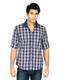

```json
{
    "title": "Turtle Check Navy Blue Men's Casual Shirt",
    "description": "Elevate your fall wardrobe with the Turtle Check Men Navy Blue Shirt, an essential for the modern man seeking style and comfort. This striking shirt features a timeless check pattern in a classic navy blue shade, perfect for any casual outing. Made from premium quality fabric, it promises a soft touch and enduring comfort throughout the day. The shirt showcases a smart full-button front, offering a versatile look that can be buttoned up or styled open with a tee underneath. Detailed with a standard collar and cuffs, this shirt is designed to seamlessly blend with both jeans and chinos for a relaxed yet refined appearance. Experience the perfect blend of contemporary style and timeless appeal with this must-have fall staple.",
    "features": [
        "Classic navy blue check pattern",
        "Premium quality fabric for all-day comfort",
        "Versatile full-button front design",
        "Standa

In [11]:
# Generate and display listings for the first row
generate_and_display_range(products_df, 0, 1)

## Step 6: Processing Multiple Products
**Objective:** Generate listings for multiple products in batch.

**What to do:**
- Loop through products
- Generate listing for each
- Save results
- Handle errors gracefully


===== ROW 0 =====


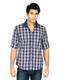

```json
{
    "title": "Stylish Turtle Check Navy Blue Men's Casual Shirt",
    "description": "Elevate your fall wardrobe with the Turtle Check Men Navy Blue Shirt, a perfect blend of style and comfort. Crafted for the modern man, this shirt features a classic check pattern in navy blue that exudes timeless elegance. The soft, breathable fabric ensures comfort throughout the day, making it an ideal choice for casual outings or weekend getaways. Designed with precise tailoring, it offers a flattering fit that pairs seamlessly with jeans or chinos for an effortlessly chic look. The shirt’s attention to detail, from its durable stitching to the neatly crafted buttons, promises long-lasting wear. Make a statement this season with a shirt that embodies sophistication and casual flair.",
    "features": [
        "Classic navy blue check pattern",
        "Soft and breathable fabric for comfort",
        "Perfect for fall casual wear",
        "Flattering tailored fit",
        "Durable sti

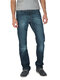

```json
{
    "title": "Peter England Men’s Party-Ready Blue Jeans",
    "description": "Step out in style this summer with the Peter England Men’s Party Blue Jeans, designed for those who appreciate a blend of comfort and fashion. These versatile jeans sport a rich blue hue, perfect for casual outings and summer gatherings. The tailored fit ensures all-day comfort, while the durable denim fabric guarantees long-lasting wear. Featuring a classic five-pocket design, these jeans are as functional as they are stylish. The subtle fade and whiskering on the thighs add a modern twist, making them ideal for any casual ensemble. Pair them with a crisp shirt or a relaxed tee to effortlessly transition from day to night. Trust Peter England for quality craftsmanship that never goes out of style.",
    "features": [
        "Rich blue denim fabric",
        "Tailored for all-day comfort",
        "Classic five-pocket design",
        "Subtle fade and whiskering details",
        "Durable material

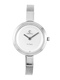

```json
{
    "title": "Elegant Titan Women Silver Watch - Timeless Casual Style",
    "description": "Elevate your accessory collection with the Titan Women Silver Watch, a harmonious blend of elegance and functionality. This stunning timepiece is perfect for casual winter outings, offering a sophisticated touch with its sleek silver finish. The minimalist design features a refined round dial and slender bracelet, making it a versatile accessory for any ensemble. Built with precision and style in mind, the watch boasts a durable metal strap and an uncomplicated clasp, ensuring both comfort and security. A subtle yet striking Titan emblem adorns the face, symbolizing quality and tradition. Ideal for those who appreciate understated luxury, this watch complements any wardrobe with ease.",
    "features": [
        "Sleek silver finish for timeless style",
        "Minimalist round dial with elegant design",
        "Durable metal strap with secure clasp",
        "Subtle Titan emblem fo

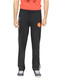

```json
{
    "title": "Manchester United Men's Black Track Pants",
    "description": "Elevate your casual style with the Manchester United Men Solid Black Track Pants, perfect for the fall season. Designed with comfort and versatility in mind, these track pants are a must-have for any fan or fashion-forward individual. Made from high-quality materials, they offer a soft, comfortable fit that's ideal for lounging at home or running errands. The solid black color is timeless and versatile, while the iconic Manchester United logo adds a touch of sporty flair. Featuring an elastic waistband with a drawstring for a customizable fit, these track pants ensure maximum comfort and flexibility. The convenient side pockets offer practicality, allowing you to keep essentials close at hand. Whether you're a dedicated fan of Manchester United or simply in search of stylish, comfortable casual wear, these track pants are your go-to choice.",
    "features": [
        "Made from high-quality materia

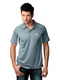

```json
{
    "title": "Puma Men's Casual Grey Polo T-Shirt",
    "description": "Step out in style this summer with the Puma Men's Grey Polo T-Shirt, tailored for the modern man. Crafted from lightweight, breathable fabric, this t-shirt ensures you stay cool and comfortable on warm days. The classic grey hue adds a touch of sophistication to your casual wardrobe, while the subtle Puma logo on the front emphasizes your love for quality and style. With a polished polo design and a flattering fit, this top is perfect for casual outings, golf sessions, or just a relaxed day at home. Pair it with your favorite jeans or shorts for an effortlessly stylish look, and enjoy the compliments that come your way.",
    "features": [
        "Classic grey color for versatile styling",
        "Lightweight, breathable fabric ideal for summer",
        "Polo collar for a sophisticated casual look",
        "Subtle Puma logo adds brand recognition",
        "Tailored fit for enhanced comfort",
        

In [12]:
# Displaying the generated listing for the first row
idx_start = 0
idx_end = 5
for idx, row in products_df.iloc[idx_start:idx_end].iterrows():
    print(f"\n===== ROW {idx} =====")

    result = generate_listing_for_row(row)
    products_df.loc[idx, "listing_raw"] = result

    display(row["image"])
    print(result)


===== ROW 0 =====


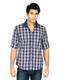

```json
{
    "title": "Stylish Navy Blue Checkered Men's Fall Shirt",
    "description": "Elevate your casual wardrobe with our Turtle Check Men Navy Blue Shirt, designed to add a touch of sophistication to your fall ensemble. This classic checkered shirt, featuring an elegant navy blue palette, is perfect for laid-back weekends or relaxed outings. Crafted from premium materials, it ensures comfort and durability throughout the season. Its tailored fit accentuates your silhouette, while the versatile design allows for easy pairing with jeans or chinos. Whether you're heading to a casual dinner or a day out with friends, this shirt promises style and confidence.",
    "features": [
        "Navy blue checkered pattern",
        "Made from high-quality fabric",
        "Tailored fit for a sleek silhouette",
        "Perfect for casual fall outings",
        "Versatile styling with collars and cuffs",
        "Comfortable and durable material",
        "Ideal for pairing with jeans or ch

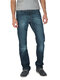

```json
{
    "title": "Stylish Peter England Blue Jeans for Men",
    "description": "Upgrade your summer wardrobe with the Peter England Men Party Blue Jeans, tailored to perfection for a casual yet sophisticated look. These jeans boast a rich blue hue with subtle fading for a modern appeal. Constructed from high-quality denim, they ensure durability and comfort all day long. The classic five-pocket design provides functionality, while the regular fit flatters various body types. Ideal for summer outings and casual gatherings, these jeans pair effortlessly with t-shirts or casual shirts, giving you a versatile style statement. Timeless and trendy, the Peter England Blue Jeans are a must-have for every fashion-forward man.",
    "features": [
        "Rich blue color with subtle fading",
        "High-quality, durable denim",
        "Classic five-pocket design",
        "Comfortable regular fit",
        "Ideal for summer and casual occasions",
        "Versatile pairing with tees or

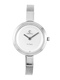

```json
{
    "title": "Elegant Silver Winter Watch for Women - Titan",
    "description": "Embrace timeless elegance with the Titan Women Silver Watch. Perfectly crafted for the winter season, this casual accessory adds a touch of sophistication to any outfit. The sleek silver design features a minimalist round dial, beautifully complemented by a durable stainless steel strap. The subtle branding and clean watch face offer a classic and refined look, while the polished finish enhances its luxurious appeal. Lightweight and comfortable, it ensures a snug fit for all-day wear. Whether you're heading to a casual brunch or a day at the office, this watch is your perfect style companion, blending functionality with fashion-forward design.",
    "features": [
        "Sleek silver design for a timeless appeal",
        "Durable stainless steel strap ensuring longevity",
        "Minimalist round dial with subtle branding",
        "Polished finish for a luxurious touch",
        "Lightweight

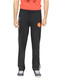

```json
{
    "title": "Manchester United Black Track Pants for Men",
    "description": "Elevate your casual style with the Manchester United Men Solid Black Track Pants. Perfect for fall, these track pants combine comfort and style, making them ideal for everyday wear. Crafted from high-quality materials, they ensure durability while offering a soft touch against the skin. The striking Manchester United emblem adds a touch of fan pride, making it a must-have for supporters. A relaxed fit and adjustable waistband provide maximum comfort, whether you're lounging at home or out and about. The sleek black color adds versatility, effortlessly matching your favorite tops. Experience the perfect blend of sporty elegance with these essential track pants.",
    "features": [
        "Official Manchester United branding",
        "Comfortable fit with adjustable waistband",
        "High-quality, durable materials",
        "Versatile solid black color",
        "Perfect for casual, everyday w

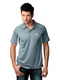

```json
{
    "title": "Men's Grey Puma T-shirt - Casual Summer Style",
    "description": "Elevate your casual wardrobe with the Puma Men Grey T-shirt, designed for ultimate comfort and style during the summer season. Crafted from lightweight, breathable fabric, this t-shirt ensures you stay cool and comfortable even on the warmest days. The modern grey hue complements any casual outfit, making it a versatile addition to your wardrobe. Featuring the iconic Puma logo on the chest, this t-shirt not only showcases brand authenticity but also adds a touch of sporty elegance to your look. Whether you're heading out for a casual day with friends or just relaxing at home, this Puma t-shirt is the perfect choice for effortless style and comfort.",
    "features": [
        "Lightweight and breathable fabric",
        "Stylish grey color for versatile pairing",
        "Iconic Puma logo on the chest",
        "Designed for casual, everyday wear",
        "Ideal for summer season comfort",
    

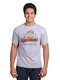

```json
{
    "title": "Inkfruit Men's Chain Reaction Grey T-shirt",
    "description": "Elevate your casual summer wardrobe with the Inkfruit Men's Chain Reaction T-shirt. Crafted in a versatile grey hue, this T-shirt features a unique and eye-catching print, embodying a vibrant chain reaction design that stands out. Made from soft, breathable fabric, it ensures comfort during those warm summer days, making it your perfect go-to for casual outings or relaxed weekends. The classic crew neck and short sleeves provide a timeless look, while the relaxed fit offers ease of movement and a laid-back vibe. Step up your style game with Inkfruit's bold design and enjoy the compliments coming your way.",
    "features": [
        "Vibrant chain reaction graphic print",
        "Comfortable and breathable fabric",
        "Classic crew neck design",
        "Short sleeves for a relaxed fit",
        "Versatile grey color",
        "Perfect for casual summer wear",
        "Durable and stylish"
  

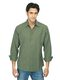

```json
{
    "title": "Fabindia Men's Striped Green Summer Ethnic Shirt",
    "description": "Elevate your summer wardrobe with the Fabindia Men's Striped Green Shirt, a perfect blend of comfort and style. Designed for the modern man, this shirt boasts a refreshing green hue that complements the vibrant energy of summer. Its subtle striped pattern adds a touch of elegance, making it ideal for both casual outings and ethnic occasions. Crafted from breathable fabric, this shirt ensures you stay cool and comfortable even on the hottest days. The classic collar and button-down design provide a timeless appeal, while the relaxed fit allows for easy movement. Pair it with your favorite jeans or chinos for a sophisticated, yet laid-back look.",
    "features": [
        "Breathable fabric ideal for summer",
        "Striking green color with subtle stripes",
        "Classic collar with a button-down design",
        "Versatile style suitable for casual and ethnic wear",
        "Relaxed fit

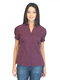

```json
{
    "title": "Chic Purple Summer Shirt for Women - Casual Elegance",
    "description": "Elevate your casual wardrobe with the Jealous 21 Women Purple Shirt, a perfect blend of style and comfort for the summer season. This eye-catching purple shirt is designed to keep you cool and stylish on warm days. Crafted from breathable, lightweight fabric, it ensures all-day comfort while maintaining a chic look. The shirt features a classic collar and short sleeves, making it a versatile piece for any casual outing. Its tailored fit enhances your silhouette, offering a flattering look for every body type. Pair it with your favorite jeans or skirts for an effortlessly stylish ensemble. Whether you're heading to a brunch or a casual day out, this shirt is a must-have addition to your summer collection. Experience the perfect blend of functionality and fashion with Jealous 21.",
    "features": [
        "Vibrant purple color adds a pop of brightness",
        "Crafted from lightweight, 

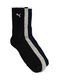

```json
{
    "title": "Puma Men's Navy Blue Casual Socks Pack of 3",
    "description": "Elevate your casual wardrobe with the Puma Men's Pack of 3 Socks, designed in a versatile navy blue shade. Perfect for the summer season, these socks offer the ideal blend of comfort and style. Crafted from high-quality materials, they ensure breathability and durability, keeping your feet cool and fresh all day long. The sophisticated design features the iconic Puma logo, adding a touch of sporty elegance to your ensemble. Whether you're stepping out for a casual outing or relaxing at home, these socks provide superior comfort and a snug fit for every occasion. Enhance your daily wear with these stylish and functional socks from Puma.",
    "features": [
        "Pack of 3 socks for value and convenience",
        "Classic navy blue color for versatile styling",
        "Breathable material perfect for summer",
        "Casual yet stylish for everyday wear",
        "Iconic Puma logo for sporty f

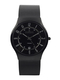

```json
{
    "title": "Elegant Skagen Men's Black Casual Winter Watch",
    "description": "Elevate your winter style with the Skagen Men's Black Watch, a perfect blend of sophistication and minimalism. Crafted for the modern man, this accessory stands out with its all-black design, featuring a sleek matte finish. The watch face displays clean lines and subtle markers, making it not just a timepiece but a statement piece. Its durable, high-quality strap ensures comfort and longevity, ideal for casual outings or office wear. Designed with precision, this watch is perfect for those who appreciate understated elegance. Enhance your wardrobe this winter with a watch that effortlessly complements any look.",
    "features": [
        "All-black sophisticated design",
        "Matte finish case and strap",
        "Minimalist dial with subtle markers",
        "Comfortable and durable strap",
        "Ideal for casual and office wear",
        "Timeless elegance for winter fashion",
       

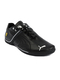

```json
{
    "title": "Puma Future Cat Remix SF Men's Black Shoes",
    "description": "Step into a world of style and comfort with the Puma Men Future Cat Remix SF Black Casual Shoes. Designed for the modern man who values both aesthetics and functionality, these shoes are a must-have for your summer wardrobe. The sleek black finish exudes a sophisticated charm, while the distinctive Puma logo adds a touch of sporty elegance. Crafted from high-quality materials, these shoes promise durability and breathability, keeping your feet cool and comfortable all day long. The ergonomic design ensures optimal foot support, making them perfect for casual outings or leisurely walks. The shoe’s streamlined silhouette and unique stitch detailing elevate your style quotient effortlessly. Experience the seamless blend of fashion and performance with every stride.",
    "features": [
        "Sleek black finish for a sophisticated look",
        "Durable materials ensure long-lasting wear",
        "

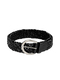

```json
{
    "title": "Stylish Black Huarache Weave Belt for Women",
    "description": "Elevate your summer wardrobe with the Fossil Women Black Huarache Weave Belt. Crafted for the modern woman, this casual yet chic accessory is perfect for adding a touch of sophistication to your ensemble. The intricate huarache weaving showcases exquisite craftsmanship, ensuring durability and style. The sleek black color complements a variety of outfits, making it an essential staple for any fashion-forward individual. Its sturdy metal buckle keeps the belt securely in place, providing both functionality and flair. Whether paired with jeans or a dress, this belt effortlessly enhances your look, making it a must-have addition to your accessory collection.",
    "features": [
        "Intricate huarache weave design",
        "Sleek black color for versatile styling",
        "Durable materials for long-lasting use",
        "Sturdy metal buckle for a secure fit",
        "Perfect for summer and ca

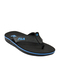

```json
{
    "title": "Fila Men's Cush Flex Black Flip Flops - Comfort Redefined",
    "description": "Step into unmatched comfort with the Fila Men Cush Flex Black Slippers. Perfect for casual outings or relaxed weekends, these flip flops are your ideal autumn companion. Crafted from durable materials, the sleek black design is accentuated by a subtle blue lining, adding a touch of modern style. The cushioned footbed offers excellent support, making every step comfortable and easy. Designed for the modern man who values both style and comfort, these slippers ensure that your feet stay relaxed while making a style statement. Slip into these stylish flip flops and experience unparalleled ease, whether strolling on the beach or lounging at home.",
    "features": [
        "Sleek black design with subtle blue accents",
        "Durable materials for long-lasting wear",
        "Cushioned footbed for supreme comfort",
        "Ideal for casual and fall outings",
        "Stylish and mode

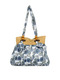

```json
{
    "title": "Chic Summer Blue Floral Handbag for Women",
    "description": "Elevate your summer wardrobe with the Murcia Women Blue Handbag, a perfect blend of style and functionality. This stunning handbag features a captivating blue floral pattern that exudes elegance and sophistication, making it a perfect accessory for casual outings. The bag is designed with sturdy handles that ensure comfort and durability for everyday use. Its unique design, with a blend of blue tones and contrasting brown accents, adds a touch of novelty and charm to your look. With ample space, you can effortlessly carry your essentials in style. The high-quality material ensures the bag is lightweight yet durable, making it an ideal choice for those sunny summer days.",
    "features": [
        "Elegant blue floral pattern",
        "Sturdy and comfortable handles",
        "Spacious interior for essentials",
        "Lightweight and durable material",
        "Contrasting brown accents",
       

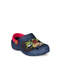

```json
{
    "title": "Ben 10 Boys Navy Blue Casual Slippers",
    "description": "Step into adventure with the Ben 10 Boys Navy Blue Slippers, perfect for little boys who love excitement and comfort. These casual slippers, featuring a vibrant Ben 10 graphic, are designed for both versatility and style. Crafted in a rich navy blue color with a contrasting playful red strap, these slippers bring a touch of superhero fun to everyday wear. The slip-on design ensures easy wearing and removal, ideal for busy kids on the go. Made from durable materials, they are tailored for the fall season, providing both comfort and a cool look. Whether at home, a playdate, or a casual outing, these slippers are the perfect choice for young Ben 10 fans!",
    "features": [
        "Navy blue slippers with Ben 10 design",
        "Vibrant red strap for easy adjustment",
        "Durable and comfortable material",
        "Slip-on style for convenience",
        "Ideal for fall and casual wear",
        "Pe

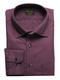

```json
{
    "title": "Reid & Taylor Men's Formal Purple Check Shirt",
    "description": "Elevate your formal wardrobe with the exquisite Reid & Taylor Men's Check Purple Shirt, the perfect addition for fall occasions. Crafted from premium fabric, this shirt combines sophistication and comfort. Its rich purple hue is designed to make a statement, while the subtle check pattern adds a touch of understated elegance. Featuring a classic collar and button-down front, this shirt ensures a polished look for any formal event. The long sleeves offer warmth during the cooler months, and the crisp cuffs provide a tailored finish. Perfect for pairing with your favorite suit or a smart pair of trousers, this shirt is an indispensable piece for the modern gentleman.",
    "features": [
        "Rich purple color with check pattern",
        "Classic collar design",
        "Premium quality fabric for comfort",
        "Button-down front for a polished look",
        "Long sleeves ideal for fall",

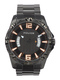

```json
{
    "title": "Sleek Police Men's Black Dial Watch PL12889JVSB",
    "description": "Elevate your casual winter style with the Police Men's Black Dial Watch PL12889JVSB. This striking accessory combines contemporary design with timeless elegance, making it a must-have for any modern gentleman. The watch features a bold black dial accented by eye-catching copper-toned markers and hands, offering exceptional readability and a touch of sophistication. Its robust case is crafted from high-quality materials, ensuring durability and a sleek look that complements any outfit. The adjustable strap guarantees comfort and ensures it sits perfectly on your wrist. Designed for the discerning man, this watch not only tells time but also makes a powerful style statement. Whether you're headed to a casual lunch or an evening gathering, this watch is the ideal companion. Stand out and embrace effortless elegance with the Police Men's Black Dial Watch.",
    "features": [
        "Bold black di

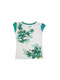

```json
{
    "title": "Gini & Jony Girls' White Floral Summer Top",
    "description": "Brighten up your girl's summer wardrobe with the Gini and Jony Girls Knit White Top. This charming top is crafted from breathable, lightweight fabric perfect for those warm, sunny days. The pristine white canvas is beautifully complemented by a burst of vivid green floral patterns, making it an eye-catching piece for casual outings. The cap sleeves in contrasting green add a playful touch, ensuring she stands out with style. The pullover design ensures ease and comfort, while the high-quality knit material promises durability and a soft feel against the skin. Ideal for pairing with shorts or jeans, this top is both versatile and fashionable, making it a must-have for every girl's summer collection.",
    "features": [
        "Breathable, lightweight fabric ideal for summer",
        "Eye-catching green floral patterns",
        "Contrasting green cap sleeves for added style",
        "Soft, comfor

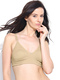

```json
{
    "title": "Bwitch Beige Full-Coverage Bra - Comfortable & Stylish",
    "description": "Discover ultimate comfort and style with the Bwitch Beige Full-Coverage Bra BW335. Expertly designed for summer casual wear, this bra offers unparalleled support and a smooth finish under any outfit. Crafted in a neutral beige hue, it's perfect for seamless wear beneath light-colored clothing. The soft fabric ensures all-day comfort, while its full coverage design provides the perfect balance of support and modesty. Adjustable straps allow for a customized fit, and the durable clasp ensures long-lasting wear. Whether for a busy day at work or a relaxed weekend outing, the Bwitch Beige Bra promises to be your go-to choice for sleek innerwear that complements your wardrobe elegantly.",
    "features": [
        "Full coverage for optimal support",
        "Soft, breathable fabric for summer comfort",
        "Neutral beige color for versatility",
        "Adjustable straps for a personali

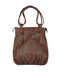

```json
{
    "title": "Elegant Brown Summer Handbag for Women - Baggit",
    "description": "Add a touch of elegance to your summer outfits with the Baggit Women Brown Handbag. This accessory, designed for casual settings, offers both style and practicality. Made from high-quality materials, its durable construction ensures it stands up to everyday use. The rich brown color complements any outfit, while the dual top handles provide comfortable carrying options. The handbag features multiple compartments to keep your essentials organized and easily accessible. A stylish zipper detail adds a touch of sophistication and security. An ideal choice for fashion-forward women, this handbag is your go-to accessory for any casual outing or summer excursion.",
    "features": [
        "Stylish brown color for versatile pairing",
        "High-quality, durable material",
        "Dual top handles for easy carrying",
        "Multiple compartments for organized storage",
        "Sophisticated zi

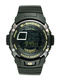

```json
{
    "title": "G-Shock Black Digital Men's Watch - Rugged & Stylish",
    "description": "Elevate your winter wardrobe with the CASIO G-Shock Men Black Digital Watch G-7710-1DR G223, a perfect fusion of rugged durability and sleek style. Designed for the modern man, this robust timepiece boasts a bold black resin strap and a resilient stainless steel case, ensuring it withstands the challenges of any casual adventure. The digital display offers clarity and precision at a glance, while the shock-resistant technology guarantees protection against everyday bumps and falls. Ideal for winter wear, this watch features a sturdy resin bezel and a durable mineral glass that resists scratches. Dive into functionality with features such as a stopwatch, countdown timer, and a reliable calendar to keep you organized. Whether you're hitting the mountains or exploring city streets, this watch is your ultimate accessory for style and resilience.",
    "features": [
        "Rugged black resin

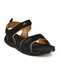

```json
{
    "title": "ADIDAS Men's Black Sandals for Casual Fall Comfort",
    "description": "Step into comfort and style with the ADIDAS Men Spry M Black Sandals, the perfect footwear choice for your casual fall outings. Crafted in a sleek black design with striking yellow accents, these sandals showcase ADIDAS's commitment to quality and innovation. Featuring adjustable Velcro straps for a secure fit, these sandals ensure a personalized experience for your feet. The durable rubber outsole provides excellent grip and stability on various surfaces, making them ideal for urban adventures or leisurely strolls in the park. Lightweight and breathable, these sandals keep your feet comfortable from morning to night. Whether you're heading to a casual lunch or a relaxed afternoon walk, these sandals are your ultimate style companion.",
    "features": [
        "Sleek black design with yellow accents",
        "Adjustable Velcro straps for a customized fit",
        "Durable rubber outsole

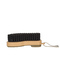

```json
{
    "title": "Timberland Unisex Rubber Sole Brush - Perfect Shine",
    "description": "Elevate your shoe care routine with the Timberland Unisex Rubber Sole Brush, a must-have accessory for maintaining the pristine appearance of your favorite footwear. Designed for casual summer outings, this versatile brush features durable black bristles ideal for cleaning and polishing rubber soles. The ergonomic wooden handle ensures a comfortable grip, making maintenance effortless. Whether restoring sneakers or maintaining everyday shoes, this brush delivers effective results every time. Compact and lightweight, it's easy to carry in your bag for on-the-go touch-ups. Invest in quality shoe care with Timberland and keep your shoes looking their best.",
    "features": [
        "Durable black bristles for effective cleaning",
        "Ergonomic wooden handle for comfort",
        "Designed for rubber sole maintenance",
        "Compact size for easy portability",
        "Ideal for casu

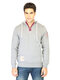

```json
{
    "title": "Adidas Men's Grey Lfc Auth Hooded Sweatshirt",
    "description": "Step up your fall wardrobe with the ADIDAS Men's Lfc Auth Hood Grey Sweatshirt. Perfectly blending style and comfort, this versatile piece is made for sports enthusiasts and casual wearers alike. Crafted with high-quality fabric, it ensures warmth and breathability during brisk autumn days. The classic grey hue offers a sleek look while the iconic Adidas logo on the sleeve stands out, embodying a legacy of sportsmanship. Featuring a comfortable hood with adjustable drawstrings and a ribbed hem, this sweatshirt promises a snug fit that's both stylish and functional. Whether you're hitting the gym or going for a relaxed weekend stroll, let this sweatshirt be your go-to topwear for effortless style and performance.",
    "features": [
        "High-quality fabric for warmth and breathability",
        "Adjustable hood with drawstrings for a personalized fit",
        "Classic grey color with distinc

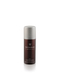

```json
{
    "title": "David Beckham Signature Men Deodorant - Fresh Scent",
    "description": "Experience the essence of sophistication with the David Beckham Signature Men Deodorant. Specially crafted for the modern man, this deodorant offers a refreshing and invigorating fragrance that embodies the spirit of spring. Encased in a sleek, white bottle with a metallic finish, it perfectly balances style and functionality. Ideal for casual wear, this deodorant keeps you fresh all day with its long-lasting protection. Whether you're at the office or out for a weekend stroll, David Beckham Signature Men Deodorant provides the confidence and freshness you need.",
    "features": [
        "Refreshing spring fragrance",
        "Long-lasting odor protection",
        "Stylish white and metallic bottle",
        "Crafted for casual wear",
        "Perfect for daily use",
        "Sophisticated scent profile",
        "Trusted by men worldwide"
    ],
    "keywords": "David Beckham deodorant

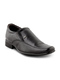

```json
{
    "title": "Elegant Buckaroo Flores Black Formal Men's Shoes",
    "description": "Elevate your formal ensemble with the Buckaroo Men Flores Black Formal Shoes, a timeless choice for sophisticated style. These shoes are crafted to perfection with premium black leather, offering a sleek and polished appearance. The elegant slip-on design ensures ease of wear while maintaining a classy look for any formal occasion. The shoes feature subtle stitching along the seams, adding a touch of refined craftsmanship. Designed for winter usage, they provide warmth and comfort without compromising on style. The durable outsole ensures long-lasting wear, making them a reliable choice for professionals who value both style and functionality. Step confidently into meetings or formal events with these exceptional shoes that embody both luxury and comfort.",
    "features": [
        "Premium black leather construction",
        "Sleek slip-on design for easy wear",
        "Subtle stitching f

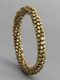

```json
{
    "title": "Elegant Bronze Beaded Bracelet for Women",
    "description": "Elevate your winter style with the Pitaraa Women Bronze Beaded Bracelet, a perfect blend of elegance and casual charm. Crafted for the modern woman, this bracelet features intricately designed bronze beads that exude sophistication and warmth. Ideal for casual outings or adding a touch of glam to your winter wardrobe, the bracelet's timeless bronze hue beautifully complements any outfit. Its durable and flexible design ensures a comfortable fit, making it a versatile addition to your accessory collection. Whether you're out with friends or enjoying a cozy day indoors, this bracelet will enhance your look with a touch of understated luxury. Discover the perfect balance of style and comfort with this exquisite piece from Pitaraa.",
    "features": [
        "Elegant bronze bead design",
        "Perfect for winter and casual occasions",
        "Durable and flexible construction",
        "Comfortable 

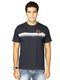

```json
{
    "title": "Fila Men's Navy Blue Sports T-shirt",
    "description": "Elevate your athletic wardrobe with the Fila Men's Round Neck Navy Blue T-shirt, a perfect blend of style and comfort for the fall season. Crafted for sports enthusiasts, this tee features a striking navy blue color with a contrasting white stripe across the chest, adding a modern touch to your activewear collection. The breathable fabric ensures maximum comfort and flexibility, making it ideal for both intense workouts and casual outings. Designed with a classic round neck and short sleeves, this t-shirt offers a versatile fit that complements various body types. Whether you're hitting the gym or enjoying a leisurely day, the Fila Men's Navy Blue T-shirt is your go-to choice for effortless style and functionality.",
    "features": [
        "Navy blue color with a white stripe design",
        "Comfortable, breathable fabric",
        "Round neck, short sleeves",
        "Suitable for fall and sports ac

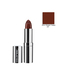

```json
{
    "title": "Colorbar Soft Touch Lipstick - Show Stopper Copper",
    "description": "Step into spring with the Colorbar Soft Touch Lipstick in Show Stopper Copper, a stunning brown hue perfect for casual outings. This luxurious lipstick glides on smoothly, providing a rich, even color that lasts all day. Encased in a sleek, metallic silver tube, it not only looks elegant but also keeps your lips hydrated with its creamy texture. The bold brown shade complements a range of skin tones, making it a versatile addition to your makeup collection. Whether you're enjoying a sunny brunch or a relaxing day at the park, this lipstick ensures you stay effortlessly chic. Embrace the warmth and vibrancy of spring with a touch of glamour.",
    "features": [
        "Rich brown color for a classic look",
        "Moisturizing formula for soft, supple lips",
        "Smooth application with long-lasting wear",
        "Elegant metallic silver packaging",
        "Perfect for casual, everyd

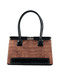

```json
{
    "title": "Murcia Women's Casual Winter Brown Handbag",
    "description": "Elevate your winter wardrobe with the Murcia Women's Casual Brown Handbag, a perfect blend of style and functionality. Crafted for the modern woman, this handbag features a rich brown hue that complements any outfit, making it an ideal accessory for casual outings. The handbag is accented with sleek black handles, offering both comfort and a touch of elegance. Its spacious interior provides ample room for all your essentials, while the durable material ensures longevity. The sophisticated design is completed with subtle metal accents for a hint of glam, making this bag a versatile addition to your collection.",
    "features": [
        "Rich brown color perfect for winter styling",
        "Sleek black handles for comfortable carrying",
        "Spacious interior for all your essentials",
        "Durable material for long-lasting use",
        "Elegant metal accents for added sophistication",
   

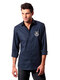

```json
{
    "title": "John Players Men's Navy Blue Formal Shirt",
    "description": "Elevate your formal wardrobe with the John Players Men Navy Blue Shirt, a perfect blend of style and elegance. Crafted for the summer season, this shirt combines comfort with a sophisticated design, making it ideal for any formal occasion. The rich navy blue color exudes confidence, while the crisp cut ensures a refined look. Notable details include a classic collar and a subtle embroidered logo on the chest, enhancing its modern appeal. Made from premium materials, this shirt promises durability and breathability, ensuring you stay comfortable and stylish all day long. Pair it with tailored trousers for an unbeatable look that commands attention and respect.",
    "features": [
        "Sophisticated navy blue color",
        "Perfect for summer formal wear",
        "Classic collar with a modern fit",
        "Embroidered chest logo for added style",
        "Breathable and comfortable fabric",
  

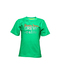

```json
{
    "title": "Disney Kids Green Sea Life T-shirt for Boys",
    "description": "Dive into summer adventures with the Disney Kids Boy's Crew Sea Life Sailing Green T-shirt. Designed for casual comfort, this vibrant green tee features an exciting sea life theme that ignites imagination and adventure. Made from soft, breathable fabric, it's perfect for keeping cool on sunny days. The eye-catching design includes charming sea motifs and playful lettering that capture the essence of summer fun. Ideal for everyday wear, this t-shirt pairs perfectly with shorts or jeans, making it a versatile addition to any young adventurer's wardrobe. Whether they're sailing the high seas of their imagination or enjoying a day at the park, kids will love the comfort and style of this unique tee.",
    "features": [
        "Vibrant green color for a refreshing summer look",
        "Soft, breathable fabric keeps kids cool and comfortable",
        "Exciting sea life design sparks creativity and fu

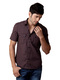

```json
{
    "title": "John Players Casual Brown Summer Shirt for Men",
    "description": "Elevate your summer style with the John Players Men Brown Shirt, designed for the modern man who values both comfort and fashion. Crafted for casual wear, this shirt is perfect for those warm days and cool evenings. Its rich brown hue provides timeless appeal, ensuring it pairs seamlessly with any wardrobe. Featuring a classic fit, this short-sleeve shirt is tailored with precision to offer maximum comfort and breathability. The button-down front and chest pocket add a touch of utility without compromising on sophistication. Whether you're heading out for a weekend adventure or a casual workday, this John Players shirt is the ultimate choice for effortless style.",
    "features": [
        "Classic short-sleeve design",
        "Rich brown color for versatile styling",
        "Made from breathable, comfortable fabric",
        "Button-down front for a polished look",
        "Convenient chest

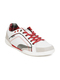

```json
{
    "title": "Elegantly Bold: Gas Men Europa White Shoes",
    "description": "Step into style with the Gas Men Europa White Shoes, a perfect blend of sophistication and comfort for your winter casual wardrobe. Crafted with sleek white leather, these shoes feature striking red laces and eye-catching black and red detailing, making them a standout addition to any outfit. The padded interior ensures warmth and comfort, essential for chilly days. Designed for effortless casual wear, these shoes offer both durability and style with a sturdy rubber sole that provides exceptional grip. Whether you're heading out for a relaxed day with friends or a casual evening event, the Gas Men Europa Shoes will keep you walking confidently and comfortably.",
    "features": [
        "Classic white leather design",
        "Bold red laces for a striking contrast",
        "Black and red detailing for added flair",
        "Comfortable padded interior for warmth",
        "Durable rubber sole wi

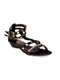

```json
{
    "title": "Stylish Black & Gold Women’s Winter Flats",
    "description": "Step out in style with the Carlton London Women Black & Gold Toned Flats, the perfect casual footwear for the winter season. These chic flat shoes feature a sleek black base with eye-catching gold-toned accents for a touch of elegance. The unique design includes two horizontal straps across the foot, embellished with gold-toned buckle details, adding both style and support. An adjustable ankle strap ensures a snug fit, while the open-toe design offers comfort and breathability. Whether you're running errands or meeting friends, these versatile flats will complement any casual winter ensemble, providing both comfort and fashion-forward flair.",
    "features": [
        "Stylish black and gold-toned design",
        "Comfortable flat sole ideal for casual wear",
        "Adjustable ankle strap for a secure fit",
        "Durable materials perfect for winter conditions",
        "Open-toe design for b

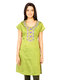

```json
{
    "title": "Elegant Green Embroidered Kurta for Women",
    "description": "Step into the vibrant hues of fall with the Diva Women Embroidered Green Kurta. Crafted for the discerning fashionista, this kurta combines traditional ethnic elements with modern sophistication. The rich green fabric serves as a perfect backdrop for the intricate embroidery adorning the neckline, giving it a timeless appeal. Designed for the fall season, this kurta is ideal for both casual outings and festive gatherings. The soft, breathable material ensures comfort throughout the day, while the tailored silhouette flatters every body type. Pair it with leggings or palazzos for a complete ethnic look that exudes elegance and grace.",
    "features": [
        "Bright green color perfect for fall",
        "Intricate embroidery on the neckline",
        "Crafted from comfortable, breathable fabric",
        "Short sleeves for a relaxed and elegant fit",
        "Ideal for ethnic and festive occasion

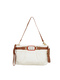

```json
{
    "title": "Chic Summer White Handbag for Women",
    "description": "Elevate your summer style with the Rocky S Women White Handbag—a perfect blend of elegance and functionality. Crafted from high-quality materials, this handbag features a pristine white body complemented by rich brown accents, exuding a sophisticated yet casual vibe. The brown shoulder strap ensures comfortable carrying while adding a touch of contrast and style. Ideal for sunny days and casual outings, this handbag is spacious enough to hold all your essentials, making it your go-to accessory for the season. The classic design transcends trends, making it a timeless addition to your accessory collection. Whether you're heading to a brunch or strolling through the market, this handbag will seamlessly complement any summer outfit.",
    "features": [
        "Elegant white color with brown accent",
        "Durable and high-quality construction",
        "Comfortable shoulder strap for easy carrying",
    

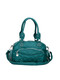

```json
{
    "title": "Kiara Women’s Stylish Teal Handbag – Summer Essential",
    "description": "Elevate your summer wardrobe with the Kiara Women Teal Handbag, a perfect blend of style and practicality. Crafted in a refreshing teal hue, this handbag is designed to add a splash of color to your casual attire. The bag features durable, high-quality materials, ensuring it withstands the hustle and bustle of everyday life. Its spacious interior provides ample room for all your essentials, making it an ideal choice for daily use. Complete with sturdy, comfortable handles and a detachable shoulder strap, this versatile handbag accommodates both hand and shoulder carry styles. The front zipper pocket adds a layer of convenience, allowing easy access to your most-needed items. Step out in style this summer with a handbag that perfectly balances elegance and functionality.",
    "features": [
        "Vibrant teal color for a standout look",
        "Spacious main compartment with secure zi

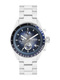

I'm unable to create a product listing based on the specific image you provided, but I can help you craft a generic listing description based on the information given. Here's an example:

```json
{
    "title": "Elegant Copper Chronograph Women's Watch",
    "description": "Elevate your style with the Fossil Women Copper Chronograph Watch CH2589. Designed for the modern woman, this exquisite timepiece effortlessly blends functionality with fashion. The warm copper hue is perfect for winter attire, adding a touch of sophistication to any casual outfit. Featuring a precision chronograph, this watch ensures accuracy and reliability. Whether attending a casual gathering or exploring a snowy cityscape, the durable design promises to be a lasting companion. Embrace timeless elegance with a watch that complements your every look.",
    "features": [
        "Warm copper finish for a stylish look",
        "Chronograph function for precise timekeeping",
        "Durable construction suitable f

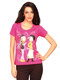

```json
{
    "title": "Stylish Pink Graphic T-shirt for Women - Jealous 21",
    "description": "Elevate your casual summer wardrobe with the Jealous 21 Women's Pink T-shirt, a vibrant and stylish choice for fashion-forward individuals. Crafted from soft, breathable cotton, this T-shirt offers comfort and durability, perfect for everyday wear. The eye-catching pink hue is complemented by a unique graphic design on the front, featuring two chic characters, adding a playful and trendy touch. Its classic round neckline and relaxed fit make it an essential piece for easy pairing with jeans, shorts, or skirts. Perfect for casual outings, this T-shirt ensures you stay cool and fashionable during those hot summer days.",
    "features": [
        "Vibrant pink color for a bold fashion statement",
        "Unique graphic design featuring chic characters",
        "Made from soft, breathable cotton material",
        "Relaxed fit for all-day comfort",
        "Classic round neckline for easy s

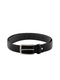

```json
{
    "title": "Elegant Peter England Men's Formal Black Belt",
    "description": "Elevate your formal attire with the Peter England Men's Formal Black Belt. Designed for the sophisticated gentleman, this belt offers a sleek and timeless look that complements any formal wardrobe. Crafted from high-quality leather, the belt boasts a refined black finish that exudes elegance and professionalism. The sturdy, silver-tone buckle adds a touch of modernity while ensuring a secure fit. Perfect for fall, this versatile accessory effortlessly enhances suits, trousers, and more. Whether you're heading to a business meeting or a formal event, this belt is your go-to choice for style and functionality.",
    "features": [
        "High-quality genuine leather material",
        "Classic and sophisticated black color",
        "Durable silver-tone buckle for a secure fit",
        "Ideal for formal occasions and fall season use",
        "Versatile design complements various outfits",
     

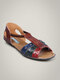

```json
{
    "title": "Stylish Women's Brown Leather Flats for Winter",
    "description": "Step into elegance and comfort with the Catwalk Women Leather Brown Flats. Crafted with premium leather, these flats offer a unique patchwork design combining earthy browns with hints of red, blue, and green, making them perfect for adding a pop of color to your winter wardrobe. The open-toe design ensures breathability, while the soft insole provides day-long comfort. Ideal for casual outings, these flats are versatile enough to complement any outfit, from jeans to dresses. Enhance your style quotient and experience unparalleled comfort with these chic leather flats, designed to keep your feet cozy during the colder months.",
    "features": [
        "Premium leather construction",
        "Unique multicolor patchwork design",
        "Comfortable open-toe style",
        "Soft, cushioned insole",
        "Durable and slip-resistant sole",
        "Versatile for casual wear",
        "Perfect

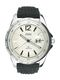

```json
{
    "title": "Maxima Ssteele Off White Men's Casual Watch",
    "description": "Elevate your winter fashion with the Maxima Ssteele Men's Off White Watch, a timeless accessory that blends style and functionality effortlessly. Designed for the modern man, this watch features an elegant off-white dial paired with a durable silver-tone stainless steel case. Its bold numeral markers and sleek hour hands ensure easy readability, while the black textured strap offers a comfortable fit for casual outings. Whether you're heading to a friend's gathering or a casual meeting, this watch is the perfect companion to make a subtle yet striking impression. Built in 2016, its classic design transcends fleeting trends, making it a worthy addition to any accessory collection. Choose Maxima Ssteele for enduring style and exceptional quality.",
    "features": [
        "Elegant off-white dial",
        "Durable silver-tone stainless steel case",
        "Bold numeral markers and sleek hour hand

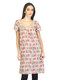

```json
{
    "title": "Chic Ethnic Beige Kurta for Women - Summer Style",
    "description": "Elevate your summer wardrobe with our W Women Printed Beige Kurta, a perfect blend of elegance and comfort. Crafted for the modern woman, this kurta features a soft beige color with intricate pink and green floral prints that reflect a timeless ethnic charm. Designed for the warm season, the lightweight fabric ensures breathable comfort all day long. The short sleeves and knee-length cut provide a flattering silhouette that pairs effortlessly with leggings or jeans for a versatile look. Whether you're attending a casual outing or a festive gathering, this kurta adds a touch of sophistication to any occasion. Embrace the season with style and grace in this must-have piece.",
    "features": [
        "Soft and breathable fabric",
        "Intricate pink and green floral prints",
        "Knee-length, suitable for various occasions",
        "Short sleeves for added comfort",
        "Versatile

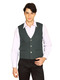

```json
{
    "title": "Stylish Men's Grey Waistcoat for Casual Fall Wear",
    "description": "Elevate your casual fall wardrobe with the Scullers Men Grey Waistcoat. This elegantly designed piece is perfect for those crisp autumn days when you want to look sharp while staying comfortable. Crafted from high-quality fabric, this waistcoat features a sophisticated grey color that adds a touch of class to any outfit. The tailored fit ensures a flattering silhouette, while the sleek button-down front provides versatility in styling. Pair it with a crisp white shirt and black trousers for a timeless look or with denim for a more relaxed vibe. Ideal for both casual outings and semi-formal gatherings, this waistcoat is a must-have addition to your wardrobe.",
    "features": [
        "Sophisticated grey color for versatile styling",
        "High-quality fabric for comfort and durability",
        "Tailored fit for a flattering silhouette",
        "Sleek button-down front for adjustable st

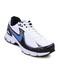

```json
{
    "title": "Nike Incinerate MSL White Blue Sports Shoe",
    "description": "Step up your game with the Nike Men's Incinerate MSL White Blue Shoe, designed for athletes who demand style and performance. Featuring a sleek white base complemented by striking blue accents, these shoes are perfect for fall sporting activities. The robust construction ensures durability, while the breathable mesh panels keep your feet cool and comfortable during intense workouts. The cushioned insole and responsive midsole provide essential support and shock absorption, enhancing your agility and speed on the field. With a superior grip outsole, these shoes offer excellent traction on various surfaces. Embrace the perfect combination of style and functionality with Nike's iconic sportswear design.",
    "features": [
        "Sleek white and blue color design",
        "Durable material for long-lasting wear",
        "Breathable mesh panels for ventilation",
        "Cushioned insole for comfor

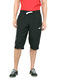

```json
{
    "title": "Puma Men's Black Bermuda Shorts - Sporty & Stylish",
    "description": "Elevate your athletic style with Puma Men Long Logo Black Bermuda Shorts, designed for active men who value both comfort and performance. Perfect for summer sports, these shorts are crafted from lightweight and breathable fabric, ensuring you stay cool and dry even during intense workouts. The sleek black hue adds a versatile touch to your athletic wardrobe, while the prominent Puma logo provides a bold brand statement. Featuring an adjustable drawstring waistband for a personalized fit, these shorts ensure maximum comfort and flexibility in motion. Whether you're hitting the gym or going for a casual walk, the functional design and sporty appeal of these shorts make them an essential addition to your collection. Pair them with a more vibrant tee for a striking contrast, and you're ready to take on the day with confidence.",
    "features": [
        "Lightweight and breathable material",
 

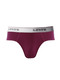

```json
{
    "title": "Levis Maroon Men's Brief with Comfort Fit",
    "description": "Discover exceptional comfort and style with the Levis Men Boxer Maroon Brief, perfect for the winter season. Crafted for casual elegance, these briefs feature a rich maroon color that adds a touch of sophistication to your innerwear collection. The premium soft fabric ensures all-day comfort, making it an ideal choice for daily wear. Designed with a stretchable waistband, these briefs provide a secure fit while offering excellent breathability. The Levis branding on the waistband adds a stylish touch, reflecting the quality and heritage of the brand. Whether you're lounging at home or on the go, these briefs ensure you stay comfortable and confident.",
    "features": [
        "Rich maroon color for a stylish look",
        "Soft fabric for all-day comfort",
        "Stretchable waistband for a secure fit",
        "Breathable material for added comfort",
        "Stylish Levis branding on the wais

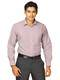

```json
{
    "title": "Elegant Red & White Striped Formal Shirt for Men",
    "description": "Step into sophistication with the John Miller Men Stripes White Red Shirt, the perfect addition to your fall formal wardrobe. This shirt features a classic red and white striped pattern, effortlessly combining style with professionalism. The crisp lines and muted colors make it an ideal choice for office settings or formal gatherings. Crafted with high-quality fabric, it offers exceptional comfort and a refined fit that enhances your silhouette. The button-down design, coupled with a standard collar, adds a touch of elegance, while the long sleeves provide warmth and coverage during the fall season. Whether paired with tailored trousers or dark denim, this versatile shirt guarantees a timeless look that transitions seamlessly from day to night.",
    "features": [
        "Classic red and white striped pattern",
        "High-quality, comfortable fabric",
        "Standard collar with button-

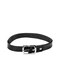

```json
{
    "title": "Chic Black Belt for Women - Perfect Summer Accessory",
    "description": "Elevate your casual summer wardrobe with the Baggit Women Hood Dabang Black Belt. Crafted for the modern woman, this sleek and versatile belt is your go-to accessory for a dash of sophistication. Made from high-quality material, the belt features a classic black color that effortlessly pairs with any outfit. Its minimalist design is complemented by a robust metallic buckle, ensuring both style and durability. Perfect for casual outings or adding a polished finish to your summer dresses, this belt is a must-have accessory. Discover timeless elegance with a contemporary twist, all in one chic belt.",
    "features": [
        "Classic black color for versatile styling",
        "Durable, high-quality material",
        "Sophisticated metallic buckle for added elegance",
        "Perfect for summer casual wear",
        "Minimalist design with modern appeal"
    ],
    "keywords": "black bel

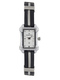

```json
{
    "title": "Elegant Maxima Women's White Dial Winter Watch",
    "description": "Elevate your winter style with the Maxima Women White Dial Watch. This sophisticated accessory combines timeless elegance with modern design, perfect for casual outings and special occasions alike. The pristine white dial is enveloped in a sleek, rectangular case that exudes class. A striking black and silver striped band adds a touch of boldness, making it a standout accessory for the season. Crafted with precision, this watch not only complements your attire but also provides reliable timekeeping. Whether you're heading to a casual brunch or a chic evening event, this watch ensures you're always fashionable and punctual.",
    "features": [
        "White rectangular dial with clear markers",
        "Stylish black and silver striped strap",
        "Durable buckle closure for secure fit",
        "Classic and modern design blend",
        "Perfect for winter and casual outings",
        "Rel

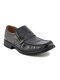

```json
{
    "title": "Clarks Men's Timeless Black Formal Leather Shoes",
    "description": "Step into sophistication with the Clarks Men Hang Work Leather Black Formal Shoes, ideal for the discerning professional. Crafted from premium leather, these black formal shoes combine classic elegance with modern functionality. The sleek design features a polished finish, ensuring you'll make a lasting impression from the boardroom to a formal event. The interior is lined with a cushioned insole, providing comfort for those long days. The durable sole offers excellent grip, perfect for navigating any urban setting. Whether you’re sealing deals or stepping out for an evening affair, these shoes offer both style and confidence. Upgrade your formal wardrobe with a pair that balances tradition and contemporary flair.",
    "features": [
        "Premium black leather construction",
        "Sleek, polished design for timeless elegance",
        "Comfortable cushioned insole for all-day wear",
  

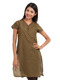

```json
{
    "title": "Chic Vishudh Women Brown Summer Kurta",
    "description": "Embrace elegance and comfort with the Vishudh Women Brown Kurta, a perfect addition to your summer ethnic wardrobe. This beautiful kurta features a rich brown hue that exudes sophistication while keeping you cool in the summer heat. Crafted with breathable, lightweight fabric, it ensures all-day comfort and style. The kurta's simple yet refined V-neckline adds a modern touch, while the exquisite short sleeves make it versatile for both casual outings and festive occasions. Pair it with your favorite leggings or palazzos to create an effortlessly chic look. Designed for women who love to blend tradition with contemporary fashion, this kurta is a must-have for those warm summer days. Experience the perfect fusion of style, comfort, and tradition.",
    "features": [
        "Rich brown color for a sophisticated look",
        "Lightweight, breathable fabric ideal for summer",
        "Modern V-neckline fo

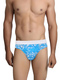

```json
{
    "title": "Men's Blue Titanium Briefs - Summer Comfort",
    "description": "Step into style and comfort with the Playboy Men Blue Titanium Briefs. Perfect for summer, these briefs are crafted from a soft, breathable fabric that keeps you cool and comfortable throughout the day. The vibrant blue color with a playful pattern adds a dynamic edge to your innerwear collection. Designed for the modern man, these briefs boast a snug fit and precision stitching for added durability. The stylish, elasticized waistband ensures a secure fit without compromising on comfort. Whether you're heading out for a casual day or lounging at home, these briefs are your go-to for seamless comfort and style.",
    "features": [
        "Vibrant blue color with playful design",
        "Breathable fabric for summer use",
        "Elasticized waistband for secure fit",
        "Soft material ensures all-day comfort",
        "Precision stitching for durability",
        "Perfect for casual, everyd

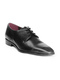

```json
{
    "title": "Sleek Black Formal Men's Shoes – Summer Elegance",
    "description": "Step into sophistication with the Arrow Men Black Formal Shoes, the perfect blend of style and comfort for the discerning gentleman. Crafted meticulously from high-quality black leather, these shoes boast a timeless design suitable for all formal occasions. The polished exterior exudes elegance, while the subtly stitched detailing adds a touch of modern flair. Inside, the shoes are lined with a soft, breathable material, ensuring your feet stay comfortable and dry even during the warmer summer months. The lace-up closure provides a secure fit, while the durable sole ensures stability and longevity. Whether you're heading to a business meeting or a formal event, these shoes will complement your attire perfectly, leaving a lasting impression.",
    "features": [
        "High-quality black leather construction",
        "Elegant polished finish",
        "Breathable inner lining for summer comf

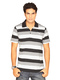

```json
{
    "title": "Stylish Black Stripe Polo T-shirt for Men by Puma",
    "description": "Elevate your casual wardrobe with the Puma Men's Stripe Polo Black T-shirt, a timeless classic designed for the modern man. Crafted with comfort and style in mind, this t-shirt features bold black and white stripes that make a striking statement. Perfect for summer, the lightweight fabric keeps you cool and comfortable all day long. The iconic Puma logo subtly accents the shirt, adding a touch of brand prestige. Whether you're heading out for a casual day with friends or a relaxed evening event, this polo ensures you always look your best. Easy to pair with your favorite jeans or shorts, it's a versatile addition to any man's closet.",
    "features": [
        "Bold black and white stripes for a classic look",
        "Lightweight fabric ideal for summer comfort",
        "Iconic Puma logo accent for a touch of brand prestige",
        "Versatile design perfect for casual occasions",
      

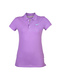

```json
{
    "title": "Stylish Women's Purple Polo T-shirt by Nike",
    "description": "Elevate your casual summer wardrobe with the Nike Women’s Purple Polo T-shirt, designed for comfort and style. Crafted from a breathable fabric, this elegant polo T-shirt promises a relaxed fit, perfect for everyday wear or a casual day out. The vibrant purple hue adds a splash of color to your look, while the classic polo collar and button placket offer a timeless appeal. The iconic Nike swoosh on the chest ensures you carry the brand's legacy wherever you go. Whether paired with jeans or shorts, this polo guarantees versatility and sophistication in every outfit.",
    "features": [
        "Breathable and comfortable fabric",
        "Vibrant purple color for a stylish look",
        "Classic polo collar with button placket",
        "Embroidered Nike swoosh on the chest",
        "Short sleeves perfect for summer",
        "Ideal for casual wear or outdoor activities"
    ],
    "keywords": "N

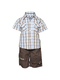

```json
{
    "title": "Gini & Jony Men's Casual White Plaid Shirt",
    "description": "Step into summer with the Gini and Jony Men's Kaleb White Brown Shirt, perfect for casual outings. This stylish shirt features a classic white base with a trendy plaid pattern in brown, offering a timeless look for any casual occasion. Crafted from lightweight, breathable fabric, it ensures maximum comfort and style during the warm months. The shirt includes a button-down front, short sleeves, and a relaxed fit, making it ideal for those laid-back summer days. Whether paired with jeans or shorts, this versatile topwear piece delivers both functionality and flair. Elevate your casual wardrobe with this must-have shirt.",
    "features": [
        "Classic white with brown plaid pattern",
        "Breathable summer-friendly fabric",
        "Button-down front",
        "Short sleeve design",
        "Relaxed fit for comfort",
        "Versatile for various casual occasions",
        "Timeless design 

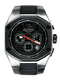

```json
{
    "title": "Sleek Carrera Men Silver Dial Steel Watch",
    "description": "Elevate your casual winter style with the Carrera Men Silver Dial Steel Watch. This exquisite timepiece boasts a sleek silver finish that effortlessly complements any outfit. The bold, black dial is enriched with three sub-dials and an eye-catching red second hand, adding a modern twist to the classic design. Encased in durable stainless steel, this watch is both robust and elegant, making it the perfect accessory for the modern man. Its comfortable steel finish strap ensures a sophisticated fit, enhancing your wrist's bold aesthetic. With precise quartz movement and reliable performance, this watch is your ideal companion for late-night dinners or leisurely winter strolls. The water-resistant feature adds an extra layer of functionality, ensuring you are ready, come rain or snow.",
    "features": [
        "Sleek silver finish strap",
        "Bold black dial with three sub-dials",
        "Eye-ca

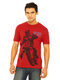

```json
{
    "title": "Wrangler Men's Red Motor Rider Tee - Fall Essential",
    "description": "Rev up your casual wardrobe with the Wrangler Men Motor Rider Red T-Shirt, designed for the modern man who values style and comfort. This bold red tee features a striking motor rider graphic, making it an ideal choice for those who love a touch of adventure. Crafted from quality material, it ensures durability and breathability, perfect for fall's crisp weather. Its classic fit and crew neck design offer a timeless silhouette, effortlessly blending comfort and style. Whether you're hitting the road or hanging out with friends, this vibrant t-shirt is your go-to for making a statement. Pair it with your favorite jeans and sneakers for an effortlessly cool look.",
    "features": [
        "Bold motor rider graphic design",
        "Vibrant red color for standout appeal",
        "Comfortable crew neck style",
        "Durable material for long-lasting wear",
        "Ideal for casual fall o

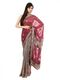

```json
{
    "title": "Glamorous Pink & Grey Wedding Saree for Women",
    "description": "Elevate your ethnic wardrobe with the exquisite FNF Pink & Grey Wedding Collection Sari, a perfect blend of tradition and contemporary elegance. This stunning saree features a harmonious combination of rich pink and subtle grey hues, designed to make a sophisticated statement at any wedding or festive occasion. Crafted with high-quality fabric, it drapes beautifully to accentuate the feminine silhouette. Intricate embroidery and detailing adorn the sari, offering a touch of luxury and opulence. Whether you’re the bride, bridesmaid, or a wedding guest, this saree ensures you stand out with grace and style. Pair it with traditional jewelry to complete your look and make unforgettable memories.",
    "features": [
        "Elegant combination of pink and grey colors",
        "High-quality fabric ensuring a perfect drape",
        "Intricate embroidery and luxurious detailing",
        "Ideal for w

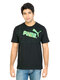

```json
{
    "title": "Puma Men's Scribble Black T-Shirt - Casual Fall Style",
    "description": "Elevate your casual wardrobe with the Puma Men's Scribble Black T-Shirt, a perfect blend of style and comfort designed for the modern man. Crafted from premium-quality cotton, this t-shirt ensures maximum comfort and breathability, making it ideal for the fall season. The striking black color serves as a versatile base, while the bold, scribble-style Puma logo in vibrant green adds a dynamic edge, making it a standout piece for any casual occasion. Designed with a classic crew neckline and short sleeves, this t-shirt offers a relaxed fit that pairs effortlessly with jeans or joggers. Whether you're heading out for a casual day with friends or a laid-back weekend errand run, this t-shirt embodies a cool and effortless charm. Experience the perfect marriage of functionality and trend with Puma, a brand synonymous with excellence.",
    "features": [
        "Premium-quality cotton fabric f

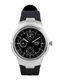

```json
{
    "title": "CASIO EDIFICE Black Dial Chronograph Watch for Men",
    "description": "Elevate your style with the CASIO EDIFICE Men Black Dial Chronograph Watch ED60. Designed for modern gentlemen, this exquisite accessory combines functionality and elegance. The sleek black dial is complemented by contrasting white and silver-tone indices, ensuring a bold yet sophisticated look. Its durable, stainless steel case offers a sturdy shield that withstands everyday wear. Perfect for winter and casual outings, the black resin band provides a comfortable fit, making it ideal for long wear. This chronograph watch features precision engineering with subdials for stopwatch functionality, catering to the needs of the active yet stylish man. Whether you're heading to the office or a casual winter gathering, this CASIO masterpiece ensures you're always in style and on time.",
    "features": [
        "Sleek black dial with white and silver-tone indices",
        "Sturdy stainless steel 

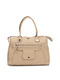

```json
{
    "title": "Chic Beige Handbag for Women - Casual Summer Essential",
    "description": "Elevate your summer style with the French Connection Women Beige Handbag, the perfect accessory for casual outings. Crafted from high-quality material, this bag seamlessly blends elegance with functionality. The classic beige color offers a timeless appeal, ensuring it complements any outfit effortlessly. Designed with a spacious interior, it provides ample room for all your essentials while the sturdy handles offer comfort and durability. The bag features an exterior pocket with a stylish button closure for quick access to your belongings, along with subtle stitching details that add a touch of sophistication. Whether you're headed to a brunch or a day of shopping, this handbag is your ideal companion, combining practical design with trend-setting style.",
    "features": [
        "Premium quality material for durability",
        "Classic beige color for versatile styling",
        "

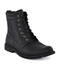

```json
{
    "title": "Stylish Timberland Men’s Black Fall Casual Shoes",
    "description": "Step into the season with the Timberland Men Black Casual Shoes, the perfect blend of style and functionality tailored for the modern man. Crafted with premium black leather, these shoes promise durability and comfort, making them your ideal partner for casual outings throughout the fall. The refined lace-up design offers a snug fit, while the robust rubber sole ensures excellent traction on various surfaces. Whether you’re heading to a relaxed weekend brunch or a casual evening stroll, these shoes provide unparalleled support and fashion-forward appeal. Their classic round-toe silhouette combined with meticulous stitching detail adds a touch of elegance to your everyday attire. For men who value both comfort and class, these Timberland shoes are a must-have addition to your footwear collection.",
    "features": [
        "Premium black leather construction",
        "Durable rubber sole for

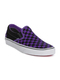

```json
{
    "title": "Vans Men's Purple Black Checkered Slip-Ons",
    "description": "Step into timeless style with the Vans Men Classic Slip-On Purple & Black Shoes, the perfect blend of comfort and bold design. Perfect for summer outings, these casual shoes boast a striking purple and black checkered pattern, making them a standout in any crowd. Crafted for the modern man who values both style and comfort, these slip-ons feature a durable canvas upper and a reliable rubber sole for excellent traction. The padded collar and elastic side accents ensure a snug fit, while the iconic Vans waffle outsole provides superior grip. Whether you're heading to a summer festival or a casual meet-up, these slip-ons offer the perfect combination of laid-back vibes and individuality.",
    "features": [
        "Classic Vans slip-on design",
        "Bold purple and black checkered pattern",
        "Durable canvas upper",
        "Comfortable padded collar",
        "Elastic side accents for easy

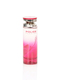

```json
{
    "title": "Enchanting Pink Passion Perfume for Women",
    "description": "Immerse yourself in the world of allure and elegance with Police Women Passion Perfume. Encased in a captivating pink ombre bottle, this fragrance is the epitome of sophistication and charm. Designed for the modern woman, its delicate yet vibrant aroma embodies the essence of spring, making it perfect for casual day-to-night transitions. Released in 2017, this scent invites you to experience the timeless passion and unique expression of femininity. Whether it’s a brunch with friends or a leisurely stroll in the park, let this perfume be your signature accessory, enhancing your grace and confidence with each spritz.",
    "features": [
        "Captivating pink ombre bottle design",
        "Ideal for casual springtime wear",
        "Released in 2017, a modern classic",
        "Delicate yet vibrant fragrance",
        "Perfect for day-to-night transitions",
        "Embodies femininity and elegance

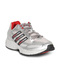

```json
{
    "title": "ADIDAS Men's Lowell White Silver Sports Shoe",
    "description": "Elevate your athletic performance with the ADIDAS Men's Lowell White Silver Shoe, designed for men who demand style and functionality. Perfect for summer sports activities, these shoes combine a sleek white and silver exterior with striking red accents for a contemporary look. Crafted for comfort, this footwear features a durable silver mesh upper to ensure breathability, keeping your feet cool and fresh. The rubber sole offers exceptional grip and stability, making it ideal for running and other high-energy sports. With iconic three-stripe detailing, these shoes not only enhance your performance but also make a bold style statement. Experience the perfect fusion of innovation and tradition with ADIDAS Lowell shoes.",
    "features": [
        "Sleek white and silver design with red accents",
        "Breathable mesh upper for enhanced airflow",
        "Durable rubber sole for superior traction"

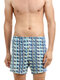

```json
{
    "title": "Stylish Men's Blue Patterned Casual Summer Shorts",
    "description": "Elevate your summer wardrobe with the Do U Speak Green Men's Blue Shorts, the perfect blend of comfort and style. Crafted for the modern man, these shorts feature an eye-catching geometric pattern in shades of blue, complemented by a flexible elastic waistband for a snug fit. Designed with both fashion and functionality in mind, these lightweight shorts are ideal for casual outings, beach days, or lounging in comfort. Their breathable fabric ensures you stay cool and relaxed even on the hottest days. The distinctive design adds a touch of flair, making them a versatile choice for any summer activity. Pair with your favorite tee or polo shirt and step out with confidence.",
    "features": [
        "Vibrant blue geometric pattern",
        "Comfortable elastic waistband",
        "Breathable, lightweight fabric",
        "Perfect for casual summer wear",
        "Versatile style for various 

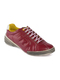

```json
{
    "title": "Stylish Red Men's Casual Shoes for Fall",
    "description": "Step into style with our ID Men Red Shoes, designed to elevate your casual fall wardrobe. These vibrant red shoes are crafted with comfort and fashion in mind, featuring a sleek leather finish that not only looks good but feels great. The striking red exterior is complemented by a contrasting yellow inner lining, offering a pop of unexpected color and a snug fit for all-day wear. The durable, textured rubber sole ensures excellent grip and long-lasting wear, making these shoes perfect for brisk fall walks or casual outings. With a lace-up design, they provide a customizable fit, ensuring your feet remain comfortable and chic throughout the day. Whether paired with jeans or chinos, these shoes are sure to become a staple in your seasonal collection.",
    "features": [
        "Vibrant red leather exterior",
        "Contrasting yellow inner lining",
        "Durable, textured rubber sole",
        "La

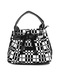

```json
{
    "title": "Chic Peperone Black & White Summer Handbag",
    "description": "Elevate your summer style with the Peperone Women Black & White Handbag, a perfect blend of elegance and practicality. This handbag features a striking black and white plaid pattern that effortlessly complements casual summer outfits. Made from premium materials, it ensures durability while maintaining a lightweight feel. The spacious interior provides ample room for your essentials, making it ideal for day trips or casual outings. The sturdy, comfortable double handles make it easy to carry, and the secure zipper closure ensures your belongings stay safe. With its modern design and versatile color scheme, this handbag is a must-have accessory for every fashion-forward woman.",
    "features": [
        "Stylish black and white plaid pattern",
        "Lightweight and durable construction",
        "Spacious interior with secure zipper closure",
        "Comfortable double handles for easy carrying

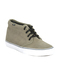

```json
{
    "title": "Vans Men's Khaki Casual Shoes - Timeless Summer Style",
    "description": "Step into summer with the effortlessly stylish Vans Men's Khaki Casual Shoes. Designed for those who appreciate comfort and flair, these shoes feature a versatile khaki color perfect for any casual look. The high-quality canvas upper allows breathability and comfort suitable for warm weather, while the sturdy rubber sole ensures durability and traction. The lace-up design offers a secure fit, making these shoes ideal for both leisurely walks and active days. With their minimalist aesthetic and iconic Vans style, these shoes make a perfect addition to any wardrobe. Embrace a timeless design that complements any casual ensemble, and enjoy the perfect blend of fashion and function.",
    "features": [
        "Versatile khaki color",
        "Breathable canvas upper",
        "Durable rubber sole",
        "Lace-up design for secure fit",
        "Iconic Vans branding",
        "Lightweight

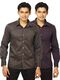

```json
{
    "title": "Indigo Nation Men's Reversible Pink Shirt - Fall Casual",
    "description": "Step up your fashion game this fall with the Indigo Nation Men's Reversible Bling Pink Shirt. Designed for the modern man, this versatile shirt offers two stylish looks in one. With its eye-catching bling pink color, this shirt effortlessly transitions from a laid-back day outing to a chic evening event. The reversible design lets you choose between two unique textures, making it a dynamic addition to your wardrobe. Crafted for comfort and style, the long sleeves and tailored fit enhance your silhouette while keeping you cozy during cool fall days. Pair it with jeans for a casual look or dress it up with trousers for a more refined ensemble.",
    "features": [
        "Reversible design offers two styles",
        "Unique bling pink color for standout style",
        "Comfortable long sleeves for warmth",
        "Tailored fit enhances your silhouette",
        "Perfect for casual and

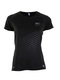

```json
{
    "title": "Nike Women's Black Fall Sports T-shirt",
    "description": "Elevate your sportswear collection with the Nike Women's Black T-shirt, crafted for both performance and style. This sleek black tee features a subtle, yet eye-catching geometric pattern across the front, adding a modern touch to your athletic wardrobe. Made from breathable, high-quality fabric, it ensures optimal comfort and moisture-wicking properties, keeping you cool and dry during your workouts. The classic round neck and short sleeves provide unrestricted movement and a flattering fit, perfect for any fall activity. Whether you're hitting the gym or enjoying a brisk outdoor run, this shirt offers versatility and timeless style. Embrace the perfect blend of fashion and functionality with Nike's signature performance wear.",
    "features": [
        "Breathable fabric for enhanced comfort",
        "Moisture-wicking properties to keep you dry",
        "Stylish geometric pattern",
        "Classic

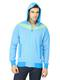

```json
{
    "title": "ADIDAS Men's Blue Fall Hoodie Sweatshirt",
    "description": "Elevate your casual wardrobe with the ADIDAS Men Blue Sweatshirt. Perfect for the fall season, this stylish hoodie offers a refreshing pop of color with its vibrant blue shade. Crafted from a soft and durable fabric, this sweatshirt ensures comfort and long-lasting wear. The design features a drawstring hood, providing extra warmth and a customizable fit. Ribbed cuffs and hem add a touch of classic styling, while enhancing the overall fit. Ideal for casual outings or lounging at home, this sweatshirt pairs effortlessly with your favorite jeans or sweatpants. Embrace the perfect blend of style and comfort with the ADIDAS Men Blue Sweatshirt, your go-to choice for every laid-back occasion.",
    "features": [
        "Vibrant blue color",
        "Soft, durable fabric",
        "Drawstring hood",
        "Ribbed cuffs and hem",
        "Perfect for fall season",
        "Casual and versatile design",
 

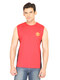

```json
{
    "title": "Bold Manchester United Red Sleeveless Tee for Men",
    "description": "Unleash your team spirit with the Manchester United Men Solid Red Sleeveless T-shirt, crafted for die-hard fans and casual wearers alike. Designed with a striking red hue, this tee is perfect for fall, giving you a vibrant touch that stands out. The sleeveless design offers versatility and comfort, suitable for a relaxed day out or a casual get-together. Emblazoned with the iconic Manchester United emblem, it gives a nod to your favorite football team. Made from premium, breathable fabric, this tee ensures you stay cool and comfortable all day long. Add this must-have piece to your wardrobe to show off your Red Devils pride in style.",
    "features": [
        "Vibrant red color",
        "Sleeveless design for maximum comfort",
        "Iconic Manchester United emblem",
        "Breathable, premium fabric",
        "Ideal for fall, casual wear"
    ],
    "keywords": "Manchester United, re

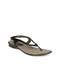

```json
{
    "title": "Rocia Women's Black Winter Flats",
    "description": "Step into style and comfort with the Rocia Women's Black Winter Flats. Designed for the modern woman, these elegant flats offer a sleek and sophisticated look perfect for casual winter outings. The refined black straps provide a touch of elegance while ensuring a secure fit, and the soft cushioned footbed promises all-day comfort. Crafted with a flexible sole, these flats allow natural foot movement, making every step effortless. Whether you're strolling through the city or enjoying a relaxed day out, these flats will keep you chic and cozy. Embrace versatility and style with footwear that effortlessly transitions from day to night.",
    "features": [
        "Elegant black straps for a chic look",
        "Cushioned footbed for maximum comfort",
        "Flexible sole for natural movement",
        "Durable materials designed for winter wear",
        "Secure fit for all-day stability",
        "Versatile 

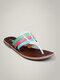

```json
{
    "title": "Stylish Women's Colorful Strap Leather Flats",
    "description": "Step into comfort and style with the Catwalk Women's Leather Flats, perfect for your casual winter outings. These chic flats feature vibrant multicolored straps in green, white, and coral red, adding a pop of color to your footwear collection. Crafted with a rich brown leather base, they provide a stylish and versatile look that complements any casual outfit. Designed for all-day comfort, these flats offer a soft insole and a durable sole that ensures stability with every step. Whether you're running errands or meeting friends for a lunch date, these flats are your go-to pair. Embrace the perfect blend of fashion and function with these standout shoes from Catwalk.",
    "features": [
        "Vibrant multicolored straps in green, white, and coral red",
        "Crafted from premium brown leather",
        "Comfortable soft insole for all-day wear",
        "Durable sole for better stability",
  

KeyboardInterrupt: 

In [14]:
# Generate and display listings for all rows
generate_and_display_range(products_df, 0, len(products_df))

In [ ]:
# Visualizing the header of the final dataset (including base64 images and raw listings)
products_df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image,image_base64,listing_raw
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,<PIL.JpegImagePlugin.JpegImageFile image mode=...,iVBORw0KGgoAAAANSUhEUgAAADwAAABQCAIAAADKqIEEAA...,"```json\n{\n ""title"": ""Stylish Turtle Check..."
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,<PIL.JpegImagePlugin.JpegImageFile image mode=...,iVBORw0KGgoAAAANSUhEUgAAADwAAABQCAIAAADKqIEEAA...,"```json\n{\n ""title"": ""Stylish Peter Englan..."
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,<PIL.Image.Image image mode=L size=60x80 at 0x...,iVBORw0KGgoAAAANSUhEUgAAADwAAABQCAAAAABgoUmPAA...,"```json\n{\n ""title"": ""Elegant Silver Titan..."
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,<PIL.JpegImagePlugin.JpegImageFile image mode=...,iVBORw0KGgoAAAANSUhEUgAAADwAAABQCAIAAADKqIEEAA...,"```json\n{\n ""title"": ""Manchester United Me..."
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,<PIL.Image.Image image mode=RGB size=60x80 at ...,iVBORw0KGgoAAAANSUhEUgAAADwAAABQCAIAAADKqIEEAA...,"```json\n{\n ""title"": ""Puma Men’s Casual Gr..."


## Challenge 1: Multi-Image Analysis
Modify your code to analyze multiple product images:
- Send 2-3 images of the same product (different angles)
- Generate a listing that incorporates details from all images
- Compare results with single-image approach

In [ ]:
pass #Current dataset has only 1 image per product

## Challenge 2: Style Customization
Add style options to your prompts:
- Formal/casual tone
- Technical/simple language
- Different target audiences
- A/B test different styles (more on this in future modules!)

## Challenge 3: Cost Tracking
Implement cost tracking:
- Calculate tokens used per request
- Track total API costs
- Estimate costs for processing large batches
- Optimize prompts to reduce costs


In [17]:
# To track a single response tokens usage:
print(response.usage)
print("Prompt tokens:", response.usage.prompt_tokens)
print("Completion tokens:", response.usage.completion_tokens)
print("Total tokens:", response.usage.total_tokens)

NameError: name 'response' is not defined

## Challenge 4: Quality Scoring
Add quality metrics:
- Check if generated listing includes all required elements
- Score listings based on length, keyword density, etc.
- Flag low-quality listings for review
- Implement automatic re-generation for low scores


## Challenge 5: Integration with E-commerce Platform
- Create a complete workflow:
- Export listings in platform-specific format (CSV, JSON)
- Include product IDs and SKUs
- Generate multiple listing variations
- Create a simple web interface for the tool